## Práctica 4 - Kmeans / Fuzzy-C
Sistemas de Aprendizaje Automático - C.E. Inteligencia Artificial y Big Data.


# Tarea 1. Carga y análisis de datos

1.1 Carga del dataset en clientes

In [ ]:
################## Carga de librerías ###################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans
!pip install scikit-fuzzy
from skfuzzy.cluster import cmeans

In [304]:
################# Carga de datos #################
url = "https://drive.google.com/uc?id=1NhUghxZk2SQzmkTrkk-yNvYCPPOHSjpQ"                                        
clientes = pd.read_csv(url)                                                                
clientes



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Procedemos a eliminar la columna "CustomerID"

In [305]:
clientes = clientes.drop(columns=["CustomerID"]) #Eliminamos la columna ID
clientes

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


1.2 Mostrar un resumen estadístico del dataset de forma numérica.

In [306]:
clientes.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


1.3 Mostrar al menos tres gráficos estadísticos sobre el dataset

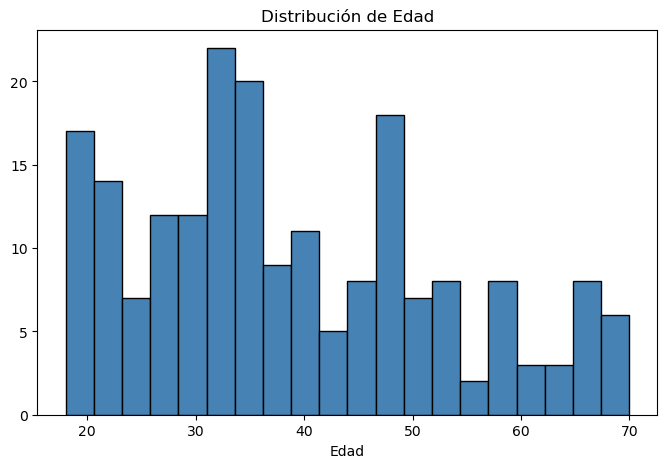

In [307]:
# Gráfico para mostrar la distribuicón de edad
plt.figure(figsize=(8, 5))                                                              
plt.hist(clientes['Age'], bins=20, color='steelblue', edgecolor='black')                
plt.xlabel('Edad')                                                                      
plt.title('Distribución de Edad')
plt.show()  

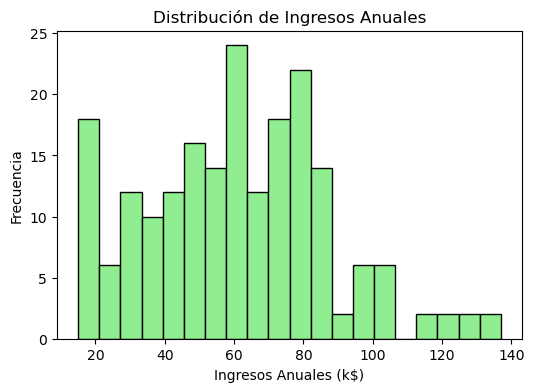

In [308]:
#Gráfica de distribución de ingresos anuales
plt.figure(figsize=(6, 4))                                                              
plt.hist(clientes['Annual Income (k$)'], bins=20, edgecolor='black',                    
color='lightgreen')                                                                     
plt.xlabel('Ingresos Anuales (k$)')                                                     
plt.ylabel('Frecuencia')                                                                
plt.title('Distribución de Ingresos Anuales')                                           
plt.show()  

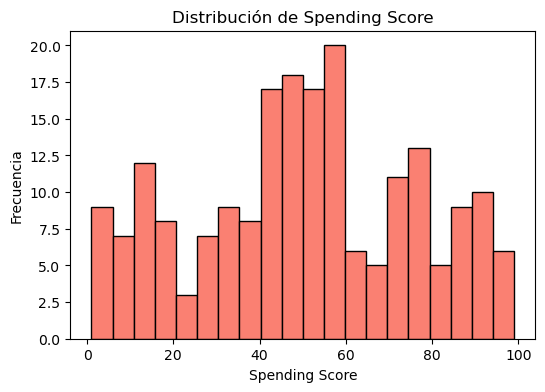

In [309]:
#Distribución del spending score
plt.figure(figsize=(6, 4))                                                        
plt.hist(clientes['Spending Score (1-100)'], bins=20, edgecolor='black',          
color='salmon')                                                                   
plt.xlabel('Spending Score')                                                      
plt.ylabel('Frecuencia')                                                        
plt.title('Distribución de Spending Score')                                     
plt.show()                                                                       
                  

1.4 Modificar la columna Gneder codificandola con 0 para male y 1 para female.

In [310]:
clientes["Gender"] = clientes["Gender"].map({"Male":0, "Female":1}) #realizamos el mapeo
clientes

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


1.5 Crea un nuevo dataset llamado clientes_std, que contenga a clientes con los
atributos escalados por el método de estandarización gaussiano

In [311]:
#Copiamos el dataframe
clientes_std = clientes.copy()

#Creamos el escalador
escalador = StandardScaler()
clientes_std = escalador.fit_transform(clientes)#Devuelve un array

clientes_std = pd.DataFrame(clientes_std, columns=clientes.columns)#Lo reconvertimos a dataframe
clientes_std

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980
...,...,...,...,...
195,0.886405,-0.276302,2.268791,1.118061
196,0.886405,0.441365,2.497807,-0.861839
197,-1.128152,-0.491602,2.497807,0.923953
198,-1.128152,-0.491602,2.917671,-1.250054


# 2. Clustering con KMeans

2.1 Mediante BIC calcula el nº óptimo de grupos para KMeans con clientes_std.
Representa gráficamente los valores de BIC obtenidos, muestra numéricamente el
valor de BIC para el mejor de los resultados y el muestra el número óptimo de
grupos obtenido.

In [312]:
#Definimos la función BIC proporcionada
def BIC(K, grupos, X):
  """
  K: Número de grupos (clusters)
  grupos: Vector que contiene los grupos de los datos
  X: Matriz de datos
  """
  N = X.shape[0] # Número de datos
  P = X.shape[1] # Número de variables
  xi = np.zeros((1,K)) # Vector xi

  # Calculamos el sumario de xi en la fórmula
  for k in range(0, K):
    suma = 0
    for j in range(0, P):
      sigma = np.square(np.std(X[:, j]))
      sigma_j = np.square(np.std(X[grupos==k, j]))
      suma += 0.5*np.log(sigma + sigma_j)

    n_k = sum(grupos==k) # Número de elementos en el grupo k
    xi[0, k] = -n_k*suma

  bic = -2*np.sum(xi) + 2*K*P*np.log(N)
  return bic

In [313]:
#Vamos a usar una nueva variable llamada X para guardarlo en formato numpy
X = clientes_std.to_numpy()
X

array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [ 0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [ 0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [ 0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [-1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [ 0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [-1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [ 0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [ 0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [ 0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [-1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [-1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [ 0.88640526, -0.

c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

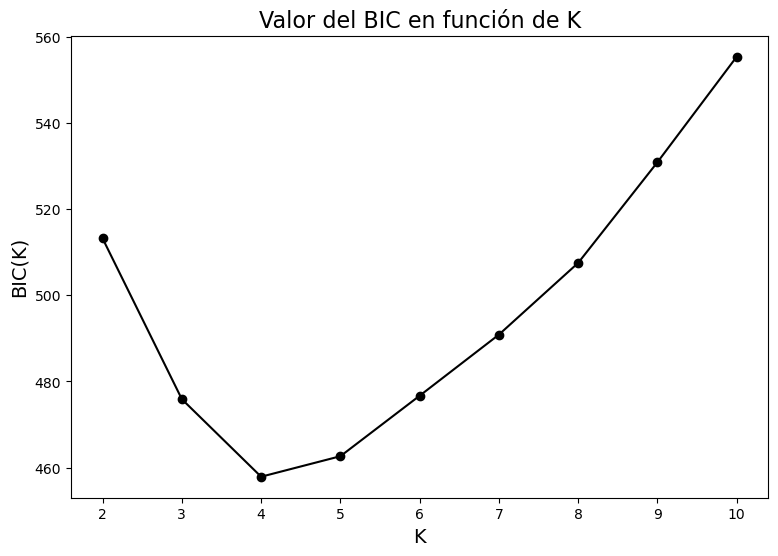

MEJOR RESULTADO:
Para K=4 se obtiene el menor BIC=457.8665951524066


In [314]:
Kmax = 10
BIC_array = []
for k in range(2, Kmax+1):
  kmeans = KMeans(n_clusters=k, n_init=15, random_state=100)
  grupos = kmeans.fit_predict(X)
  BIC_array.append(BIC(k, grupos, X))

# Dibujamos el BIC obtenido para cada valor de k
plt.figure(figsize=(9, 6))
plt.plot(np.arange(2, Kmax+1), BIC_array, "ko-")
plt.title("Valor del BIC en función de K", fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("BIC(K)", fontsize=14)
plt.show()

# Obtiene el BIC minimo.
best_BIC = min(BIC_array)

# Obtiene el K con BIC mínimo (+2 porque el bucle empieza en 2).
best_K = np.argmin(BIC_array) + 2

#Muestra el mejor resultado.
print(f"MEJOR RESULTADO:\nPara K={best_K} se obtiene el menor BIC={best_BIC}")

Obtenemos un k óptimo en 4, procedemos a realizar el agrupamiento usando KMeans

2.2 Realiza el agrupamiento de clientes_std usando KMeans, con el valor óptimo de k
obtenido en el paso anterior

In [315]:
#Guardamos la mejor k para hacer el agrupamiento
K = best_K
kmeans = KMeans(n_clusters=K, n_init=15, random_state=10)
pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_ #Obtenemos los centroides

c:\Users\David\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


2.3 Crea el dataset clientes_kmeans, que contendrá a clientes_std, con una columna
añadida con el grupo al que pertenece cada fila

In [316]:
#Creamos el dataset clientes_kmeans (clientes_std + columna de grupo)
clientes_kmeans = clientes_std.copy()
clientes_kmeans['Grupo'] = pred
clientes_kmeans

,Gender,Age,Annual Income (k$),Spending Score (1-100),Grupo
0,-1.128152,-1.424569,-1.738999,-0.434801,1
1,-1.128152,-1.281035,-1.738999,1.195704,1
2,0.886405,-1.352802,-1.700830,-1.715913,0
3,0.886405,-1.137502,-1.700830,1.040418,2
4,0.886405,-0.563369,-1.662660,-0.395980,2
...,...,...,...,...,...
195,0.886405,-0.276302,2.268791,1.118061,2
196,0.886405,0.441365,2.497807,-0.861839,0
197,-1.128152,-0.491602,2.497807,0.923953,1
198,-1.128152,-0.491602,2.917671,-1.250054,3


2.4 Muestra un gráfico donde se representen los atributos Annual Income y Spending
Score de clientes (no de clientes_std), con el color del grupo al que los ha asignado
Kmeans. Muestra también en el gráfico los centroides del agrupamiento (CUIDADO,
los centroides de clientes, no de clientes_std). Muestra numéricamente los campos
Annual Income y Spending Score de los centroides del agrupamiento.

In [317]:
X_clientes = clientes.to_numpy()

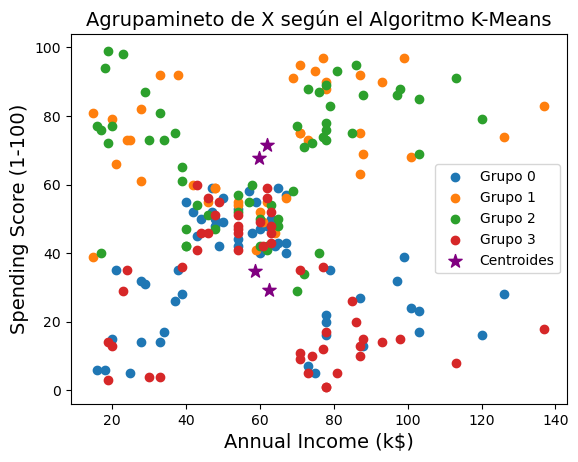

In [318]:

#Mostramos los puntos de las columnas annual income y spending score
for k in range(0, K):
  plt.scatter(X_clientes[pred==k, 2], X_clientes[pred==k, 3], label="Grupo {}".format(k))

#Desestandarizamos los centroides
centroides = escalador.inverse_transform(centroides)
centroides = centroides[:,[2,3]]

plt.scatter(centroides[:, 0],                                                    
            centroides[:, 1],                                                    
            c='purple', marker='*', s=100, label='Centroides') 

plt.title("Agrupamineto de X según el Algoritmo K-Means", fontsize=14)
plt.xlabel(clientes.columns[2], fontsize=14)
plt.ylabel(clientes.columns[3], fontsize=14)
plt.legend()
plt.show()

2.5 Analiza la siguiente cuestión: Al observar el gráfico, ¿tenemos la certeza de
comprender completamente la estructura del agrupamiento? ¿Podemos determinar
con seguridad, solo viendo el gráfico, si existe solapamiento entre grupos o si los
centroides están correctamente centrados, o podrían parecer desplazados o poco
representativos? Justifica tu respuesta

No, para este caso no existe certeza completa. 

El gráfico representa solo 2 de las 4 variables del ejercicio, por tanto los problemas de representar 2 de las 4 variables en 2D son los siguientes:
- En 2 dimensiones no se puede apreciar si hay solapamiento real en todas las dimensiones.
- Solo se representan Annual Income y Spending Score, mientras que Gender y Age no se visualizan.
- Los centroides pueden no ser representativos, ya que es imposible saber, al menos a simple vista, si existen formas irregulares de clustering, densidad desigual o si existe algún outlier que "tire" del centroide (aunque sabemos que este caso está limpio de outliers).

# 3. Clustering con Fuzzy-C

3.1 Mediante Xie-Beni calcula el nº óptimo de grupos para Fuzzy-C con clientes_std.
Representa gráficamente los valores de Xie-Beni obtenidos, muestra numéricamente
el valor de Xie-Beni para el mejor de los resultados y muestra el número óptimo de
grupos obtenido

Comenzamos definiendo la función de Xie_Beni

In [319]:
# DEFINICIÓN DE LA FUNCIÓN XIE-BENI:
def xie_beni(X, u, d, k, cntr, m):
    # Numerador: suma de u_ij^m * ||x_j - v_i||^2
    numerador = np.sum((u ** m) * (d ** 2))
    # Denominador: n * distancia mínima entre centros al cuadrado
    dist_centros = []
    for i in range(k):
        for j in range(i + 1, k):
            dist_centros.append(np.sum((cntr[i] - cntr[j]) ** 2))
    denominador = X.shape[0] * np.min(dist_centros)
    return numerador / denominador

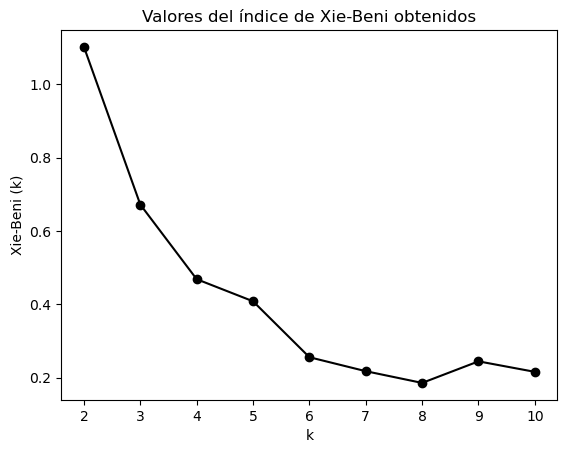

Valor óptimo de Xie-Beni: 0.18529616215603928
Número óptimo de grupos para Fuzzy-C con X, según Xie-Beni: 8


In [320]:
m=2
Kmax = 10
XB_array = []
for k in range(2, Kmax + 1):
    cntr, u, _, d, _, _, _ = cmeans(X.T, k, m, error=0.005, maxiter=1000, seed=100)
    XB_array.append(xie_beni(X, u, d, k, cntr, m))
# En este caso, la función Xie-Beni sí tiene en cuenta el porcentaje de pertenencia de cada elemento a los grupos

# Represento gráficamente los valores de Xie-Beni obtenidos:
plt.plot(np.arange(2, Kmax + 1), XB_array, "ko-")
plt.title("Valores del índice de Xie-Beni obtenidos")
plt.xlabel("k")
plt.ylabel("Xie-Beni (k)")
plt.show()

# Enseño el valor óptimo de k, según Xie-Beni.
# Mejor valor de Xie-Beni: El menor.
xb_optimo = np.amin(XB_array)
k_optimo_xb = np.argmin(XB_array) + 2   # k óptimo
print("Valor óptimo de Xie-Beni:", xb_optimo)
print("Número óptimo de grupos para Fuzzy-C con X, según Xie-Beni:", k_optimo_xb)

3.2 Realiza el agrupamiento de clientes_std usando Fuzzy-C, con el valor óptimo de k
obtenido en el paso anterio

In [321]:
# Entreno Fuzzy-C con X_nueva (con el nuevo valor óptimo de k obtenido):
cntr, u, _,_,_,_,_ = cmeans(X.T, k_optimo_xb, m=2, error=0.005, maxiter=1000, seed=100)
grupos = np.argmax(u, axis=0)
maxU = np.amax(u, axis=0)

3.3 Crea el dataset clientes_fuzzy, que contendrá a clientes_std, con una columna
añadida con el grupo al que pertenece cada fila. Muestra los centroides del
agrupamiento y la “tabla” clientes_fuzzy.

In [322]:
#Creamos la copia de clientes_std
clientes_fuzzy = clientes_std.copy()
clientes_fuzzy['Grupo'] = grupos
clientes_fuzzy

,Gender,Age,Annual Income (k$),Spending Score (1-100),Grupo
0,-1.128152,-1.424569,-1.738999,-0.434801,1
1,-1.128152,-1.281035,-1.738999,1.195704,1
2,0.886405,-1.352802,-1.700830,-1.715913,4
3,0.886405,-1.137502,-1.700830,1.040418,4
4,0.886405,-0.563369,-1.662660,-0.395980,4
...,...,...,...,...,...
195,0.886405,-0.276302,2.268791,1.118061,0
196,0.886405,0.441365,2.497807,-0.861839,6
197,-1.128152,-0.491602,2.497807,0.923953,2
198,-1.128152,-0.491602,2.917671,-1.250054,5


In [323]:
#Mostramos los centroides
cntr

array([[ 0.84066712, -0.51403302,  0.71845007,  1.11783058],
       [-1.00925083, -1.00605404, -0.50209931,  0.26062176],
       [-1.05468792, -0.33594371,  0.67181796,  1.23635499],
       [ 0.82892526,  0.7575368 , -0.37267153, -0.16633304],
       [ 0.81660977, -0.78234973, -0.63480883,  0.13351995],
       [-1.03478637,  0.16858691,  0.76739469, -1.3128222 ],
       [ 0.76251838,  0.20561601,  0.78427963, -0.95330818],
       [-1.04748714,  1.52451569, -0.29713181, -0.13420127]])

3.4 Muestra un gráfico donde se representen los atributos Annual Income y Spending
Score de clientes (no de clientes_std), con el color del grupo mayoritario al que los ha
asignado Fuzzy-C y el grado de pertenencia a su grupo. Muestra también en el
gráfico los centroides del agrupamiento (CUIDADO, los centroides de clientes, no de
clientes_std). Muestra numéricamente los campos Annual Income y Spending Score
de los centroides del agrupamiento.

In [324]:
#Realizamos la inversa para desescalar los centroides
cntr = escalador.inverse_transform(cntr)

In [325]:
centroides_fuzzy = cntr[:, [2, 3]]
print("Centroides de Fuzzy-C (Annual Income y Spending Score):")
for i, centroide in enumerate(centroides_fuzzy):
    print(f"Grupo {i+1}: Annual Income = {centroide[0]:.2f} k$, Spending Score = {centroide[1]:.2f}")

Centroides de Fuzzy-C (Annual Income y Spending Score):
Grupo 1: Annual Income = 79.38 k$, Spending Score = 78.99
Grupo 2: Annual Income = 47.41 k$, Spending Score = 56.91
Grupo 3: Annual Income = 78.16 k$, Spending Score = 82.05
Grupo 4: Annual Income = 50.80 k$, Spending Score = 45.92
Grupo 5: Annual Income = 43.93 k$, Spending Score = 53.64
Grupo 6: Annual Income = 80.66 k$, Spending Score = 16.38
Grupo 7: Annual Income = 81.11 k$, Spending Score = 25.64
Grupo 8: Annual Income = 52.78 k$, Spending Score = 46.74


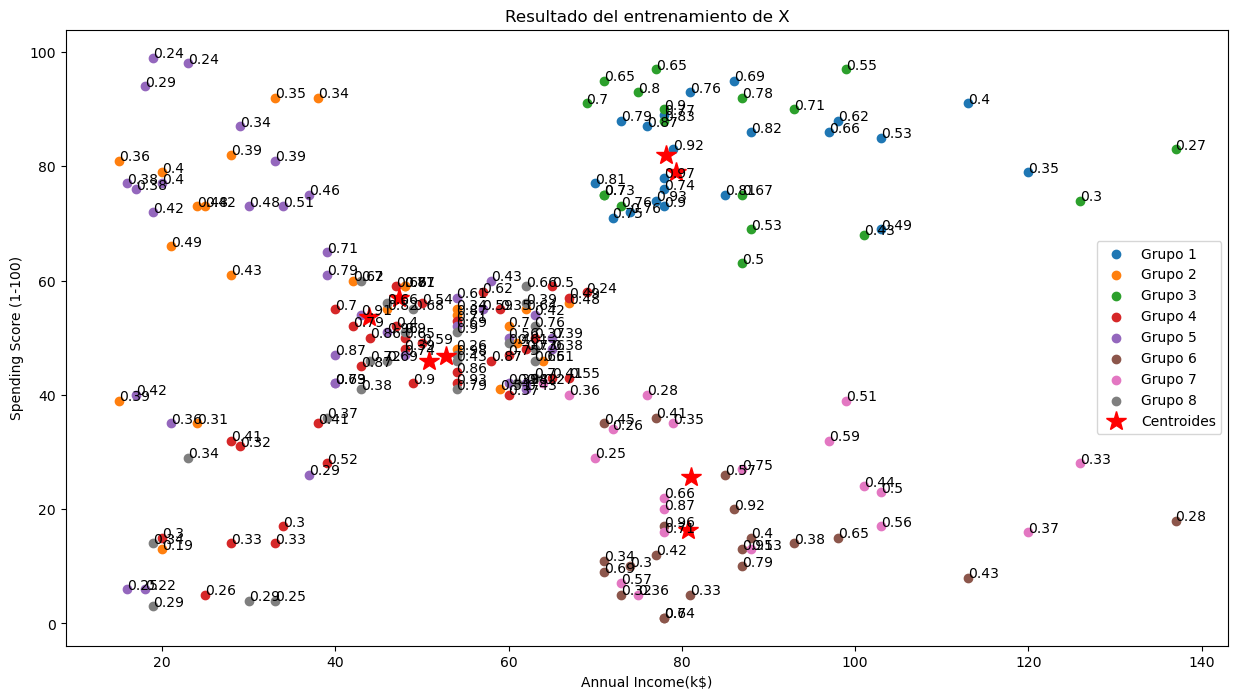

In [326]:
# Represento gráficamente el resultado del entrenamiento, incluyendo los centroides y el grado de pertenencia de cada observación:
plt.figure(figsize=(15, 8))
for k in range(0, k_optimo_xb):
    plt.scatter(X_clientes[grupos==k, 2], X_clientes[grupos==k, 3], label="Grupo {}".format(k + 1))
for i, maxU_i in enumerate(np.round(maxU, 2)):
    plt.annotate(maxU_i, (X_clientes[i,2], X_clientes[i,3]))
plt.plot(cntr[:, 2], cntr[:, 3], '*', markersize=15, c='red', label="Centroides")
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Resultado del entrenamiento de X')
plt.legend()
plt.show()

3.5 Analiza la siguiente cuestión: Al observar el gráfico, ¿tenemos la certeza de
comprender completamente la estructura del agrupamiento? ¿Podemos determinar
con seguridad, solo viendo el gráfico, si existe solapamiento entre grupos o si los
centroides están correctamente centrados, o podrían parecer desplazados o poco
representativos? Justifica tu respuesta.

No, para este caso no existe certeza completa. 

El gráfico representa solo 2 de las 4 variables del ejercicio, por tanto los problemas de representar 2 de las 4 variables en 2D son los siguientes:
- En 2 dimensiones no se puede apreciar si hay solapamiento real en todas las dimensiones.
- Solo se representan Annual Income y Spending Score, mientras que Gender y Age no se visualizan.
- Los centroides pueden no ser representativos, ya que es imposible saber, al menos a simple vista, si existen formas irregulares de clustering, densidad desigual o si existe algún outlier que "tire" del centroide (aunque sabemos que este caso está limpio de outliers).

# Tarea 4. Comparativa final y descarga de resultados

4.1 Crea el dataframe clientes_agrupados, que contendrá a clientes (no a clientes_std)
más dos columnas: El grupo al que lo asignó Kmeans y el grupo al que lo asignó
Fuzzy-C.

In [327]:
clientes_agrupados = clientes.copy() #Sacamos la copia desde clientes
clientes_agrupados["Grupo_kmeans"] = pred #Añadimos desde la predicción de kmeans
clientes_agrupados["Grupo_fuzzyC"] = grupos #Añadimos desde los grupos de fuzzy-C

clientes_agrupados

,Gender,Age,Annual Income (k$),Spending Score (1-100),Grupo_kmeans,Grupo_fuzzyC
0,0,19,15,39,1,1
1,0,21,15,81,1,1
2,1,20,16,6,0,4
3,1,23,16,77,2,4
4,1,31,17,40,2,4
...,...,...,...,...,...,...
195,1,35,120,79,2,0
196,1,45,126,28,0,6
197,0,32,126,74,1,2
198,0,32,137,18,3,5


4.2 Guarda el dataset clientes_agrupados en el disco local del equipo donde se esté
ejecutando el cuaderno de Google Colab, con el nombre
clientes_agrupados_nombre_apellido1_apellido2.csv.

In [ ]:
from google.colab import files
clientes_agrupados.to_csv('clientes_agrupados_david_medina_ruiz.csv')
files.download('clientes_agrupados_david_medina_ruiz.csv')

ModuleNotFoundError: No module named 'google.colab'

4.3 Redacta, en un cuadro de texto, un análisis completo de los resultados obtenidos

Los resultados muestran que tanto KMeans como Fuzzy-C identifican estructuras de agrupamiento significativas en los datos de clientes.              
La diferencia en el número óptimo de grupos entre ambos métodos refleja sus diferentes aproximaciones: KMeans busca grupos bien separados y compactos, mientras que Fuzzy-C permite mayor flexibilidad al permitir membresías parciales. 

- KMeans (K=4) vs Fuzzy-C (K=8)
- Fuzzy-C permite membresías parciales, dando información sobre el grado de pertenencia de cada cliente a cada grupo
- El mayor número de grupos en Fuzzy-C (8 vs 4) permite capturar subgrupos más específicos
- Fuzzy-C es más adecuado cuando hay solapamiento entre grupos, mientras que KMeans asigna cada punto a un único cluster